In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage import io
import json
import sys
from pathlib import Path
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Add parent to path
sys.path.insert(0, str(Path('../').resolve()))

# Set plot style
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("✅ Libraries loaded.")

✅ Libraries loaded.


## Configuration

Define the 3 images to compare:

In [7]:
# Define the 3 images to compare
IMAGE_CONFIGS = {
    'Original Image': {
        'image_path': Path('../Original Image/Histopathology Image.jpg'),
        'output_dir': Path('../output_results/Original_Image/Original_Image'),
    },
    'AI Gen 1 (GPT)': {
        'image_path': Path('../GPT Image Gen/653601e7-f502-43f3-bc50-c682685b7c3a.png'),
        'output_dir': Path('../output_results/AI_Gen_1_GPT/AI_Gen_1_GPT'),
    },
    'AI Gen 2 (Gemini)': {
        'image_path': Path('../Gemini Nano Banana/unnamed.jpg'),
        'output_dir': Path('../output_results/AI_Gen_2_Gemini/AI_Gen_2_Gemini'),
    }
}

# Verify images exist
print("📁 Image Paths:")
for name, config in IMAGE_CONFIGS.items():
    exists = '✅' if config['image_path'].exists() else '❌'
    print(f"   {exists} {name}: {config['image_path']}")

📁 Image Paths:
   ✅ Original Image: ..\Original Image\Histopathology Image.jpg
   ✅ AI Gen 1 (GPT): ..\GPT Image Gen\653601e7-f502-43f3-bc50-c682685b7c3a.png
   ✅ AI Gen 2 (Gemini): ..\Gemini Nano Banana\unnamed.jpg


## Helper Functions

In [3]:
def load_analysis_data(output_dir):
    """Load all analysis data from output directory."""
    data = {}
    
    # Load graph
    graphml_path = output_dir / 'rag.graphml'
    data['graph'] = nx.read_graphml(graphml_path) if graphml_path.exists() else None
    
    # Load nodes
    nodes_path = output_dir / 'nodes.csv'
    data['nodes'] = pd.read_csv(nodes_path) if nodes_path.exists() else None
    
    # Load centrality
    centrality_path = output_dir / 'centrality.csv'
    data['centrality'] = pd.read_csv(centrality_path) if centrality_path.exists() else None
    
    return data


def get_node_positions_from_centroids(nodes_df):
    """Get node positions from centroid coordinates."""
    pos = {}
    if nodes_df is not None and 'centroid_row' in nodes_df.columns:
        for _, row in nodes_df.iterrows():
            node_id = str(int(row['node']))
            pos[node_id] = (row['centroid_col'], row['centroid_row'])
    return pos


def draw_network_on_image(ax, image, G, nodes_df, centrality_df=None, 
                          title="Network Graph", color_by='community',
                          node_size=80, edge_alpha=0.6, show_labels=False):
    """Draw network graph overlaid on the original image."""
    ax.imshow(image)
    
    if G is None:
        ax.set_title(f"{title}\n(No graph data)", fontsize=11)
        ax.axis('off')
        return
    
    # Get positions from centroids
    pos = get_node_positions_from_centroids(nodes_df)
    valid_pos = {n: pos[n] for n in G.nodes() if n in pos}
    
    if not valid_pos:
        # Fallback to spring layout scaled to image
        valid_pos = nx.spring_layout(G, seed=42)
        h, w = image.shape[:2]
        for n in valid_pos:
            valid_pos[n] = (valid_pos[n][0] * w * 0.8 + w * 0.1,
                           valid_pos[n][1] * h * 0.8 + h * 0.1)
    
    # Get node colors
    if color_by == 'community' and centrality_df is not None and 'community_id' in centrality_df.columns:
        comm_map = dict(zip(centrality_df['node'].astype(str), centrality_df['community_id']))
        unique_comms = sorted(set(comm_map.values()))
        n_comms = max(len(unique_comms), 1)
        cmap = plt.cm.Set3
        colors = [cmap(comm_map.get(n, 0) / max(n_comms - 1, 1)) for n in G.nodes() if n in valid_pos]
    elif color_by == 'betweenness' and centrality_df is not None and 'betweenness' in centrality_df.columns:
        cent_map = dict(zip(centrality_df['node'].astype(str), centrality_df['betweenness']))
        values = [cent_map.get(n, 0) for n in G.nodes() if n in valid_pos]
        max_val = max(values) if values and max(values) > 0 else 1
        colors = plt.cm.YlOrRd(np.array(values) / max_val)
    else:
        colors = 'cyan'
    
    # Draw edges
    edge_list = [(u, v) for u, v in G.edges() if u in valid_pos and v in valid_pos]
    nx.draw_networkx_edges(G, valid_pos, edgelist=edge_list, 
                           alpha=edge_alpha, width=1.5, edge_color='white', ax=ax)
    
    # Draw nodes
    nodelist = [n for n in G.nodes() if n in valid_pos]
    nx.draw_networkx_nodes(G, valid_pos, nodelist=nodelist,
                           node_color=colors, node_size=node_size, 
                           alpha=0.9, edgecolors='white', linewidths=0.5, ax=ax)
    
    if show_labels:
        nx.draw_networkx_labels(G, valid_pos, font_size=5, font_color='yellow', ax=ax)
    
    ax.set_title(title, fontsize=11, fontweight='bold', color='white',
                 bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    ax.axis('off')


def draw_network_standalone(ax, G, centrality_df=None, title="Network Graph", 
                            color_by='community', node_size=200):
    """Draw standalone network graph."""
    if G is None:
        ax.text(0.5, 0.5, 'No graph data', ha='center', va='center', fontsize=14)
        ax.set_title(title)
        ax.axis('off')
        return
    
    pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
    
    # Get node colors
    if color_by == 'community' and centrality_df is not None and 'community_id' in centrality_df.columns:
        comm_map = dict(zip(centrality_df['node'].astype(str), centrality_df['community_id']))
        unique_comms = sorted(set(comm_map.values()))
        n_comms = max(len(unique_comms), 1)
        cmap = plt.cm.Set3
        colors = [cmap(comm_map.get(n, 0) / max(n_comms - 1, 1)) for n in G.nodes()]
    else:
        colors = 'steelblue'
    
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_size, alpha=0.8, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')


print("✅ Helper functions defined.")

✅ Helper functions defined.


## Run Pipeline on All Images

In [5]:
from superpixel_rag.config import Config
from superpixel_rag.pipeline import Pipeline

# Run pipeline on each image
for name, config in IMAGE_CONFIGS.items():
    if not config['image_path'].exists():
        print(f"⚠️ Skipping {name}: Image not found")
        continue
    
    output_dir = config['output_dir']
    manifest_path = output_dir / 'manifest.json'
    
    # Skip if already processed
    if manifest_path.exists():
        print(f"✅ {name}: Already processed")
        continue
    
    print(f"🔄 Processing {name}...")
    
    # Create output directory name
    run_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    
    # Create config with proper output_dir
    cfg = Config()
    cfg.output_dir = str(output_dir)
    cfg.show_plots = False
    cfg.save_plots = False
    
    pipeline = Pipeline(cfg)
    
    try:
        bundle = pipeline.run(str(config['image_path']), title=run_name)
        print(f"✅ {name}: Processed successfully")
    except Exception as e:
        print(f"❌ {name}: Error - {e}")

print("\n🎉 Pipeline processing complete!")

🔄 Processing Original Image...
Loaded image from: ..\Original Image\Histopathology Image.jpg
  Shape: (640, 640, 3), dtype: uint8

Processing: Original_Image
SLIC segmentation: 86 superpixels
RAG built: 86 nodes, 218 edges
Number of nodes: 86
Number of edges: 218
Degree stats: min=2, max=11, mean=5.07
Graph connected: True

Enriching: Original_Image
Extracted features for 86 regions
Edge weights computed using mode: mean_color_distance
Weight stats: min=0.0000, max=0.6909, mean=0.1512
Pruning mode: threshold, value: 0.2
Removed 162 edges, 31 isolated nodes
Pruned graph: 55 nodes, 56 edges

Analyzing: Original_Image

Graph Statistics:
  Nodes: 55, Edges: 56
  Connected components: 6
  Largest component size: 38

Using weight attribute: 'weight2'
Computing centrality measures...
Merged with region features

Top 15 nodes by betweenness centrality:
    node  betweenness  closeness  eigenvector  degree  weighted_degree  \
14    20     0.516517   0.498849     0.418655       6        15.58919

## Load All Data

In [8]:
# Load all images and data
all_data = {}

for name, config in IMAGE_CONFIGS.items():
    all_data[name] = {'config': config, 'image': None, 'analysis': None}
    
    # Load image
    if config['image_path'].exists():
        all_data[name]['image'] = io.imread(str(config['image_path']))
        h, w = all_data[name]['image'].shape[:2]
        print(f"✅ {name}: Image {w}x{h}")
    else:
        print(f"❌ {name}: Image not found")
    
    # Load analysis data
    if config['output_dir'].exists():
        all_data[name]['analysis'] = load_analysis_data(config['output_dir'])
        G = all_data[name]['analysis'].get('graph')
        if G:
            print(f"   📊 Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    else:
        print(f"⚠️ {name}: No analysis data")

✅ Original Image: Image 640x640
   📊 Graph: 38 nodes, 44 edges
✅ AI Gen 1 (GPT): Image 1536x1024
   📊 Graph: 26 nodes, 27 edges
✅ AI Gen 2 (Gemini): Image 1024x559
   📊 Graph: 69 nodes, 89 edges


---
# Network Graph Visualizations
---

## 1. Original Images - Side by Side

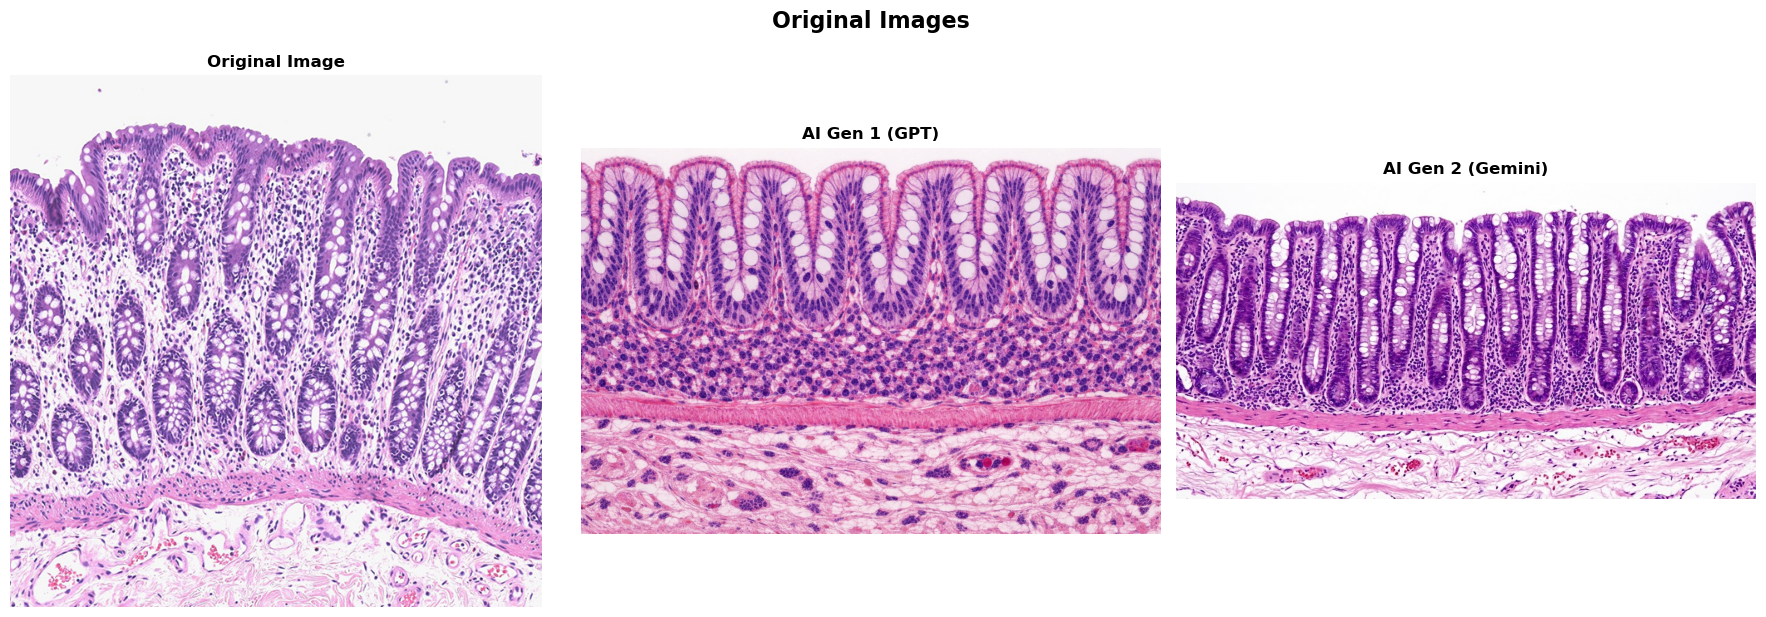

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, data) in zip(axes, all_data.items()):
    if data['image'] is not None:
        ax.imshow(data['image'])
        ax.set_title(name, fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Image not available', ha='center', va='center')
        ax.set_title(name)
    ax.axis('off')

plt.suptitle('Original Images', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Network Graphs Overlaid on Images (Community Coloring)

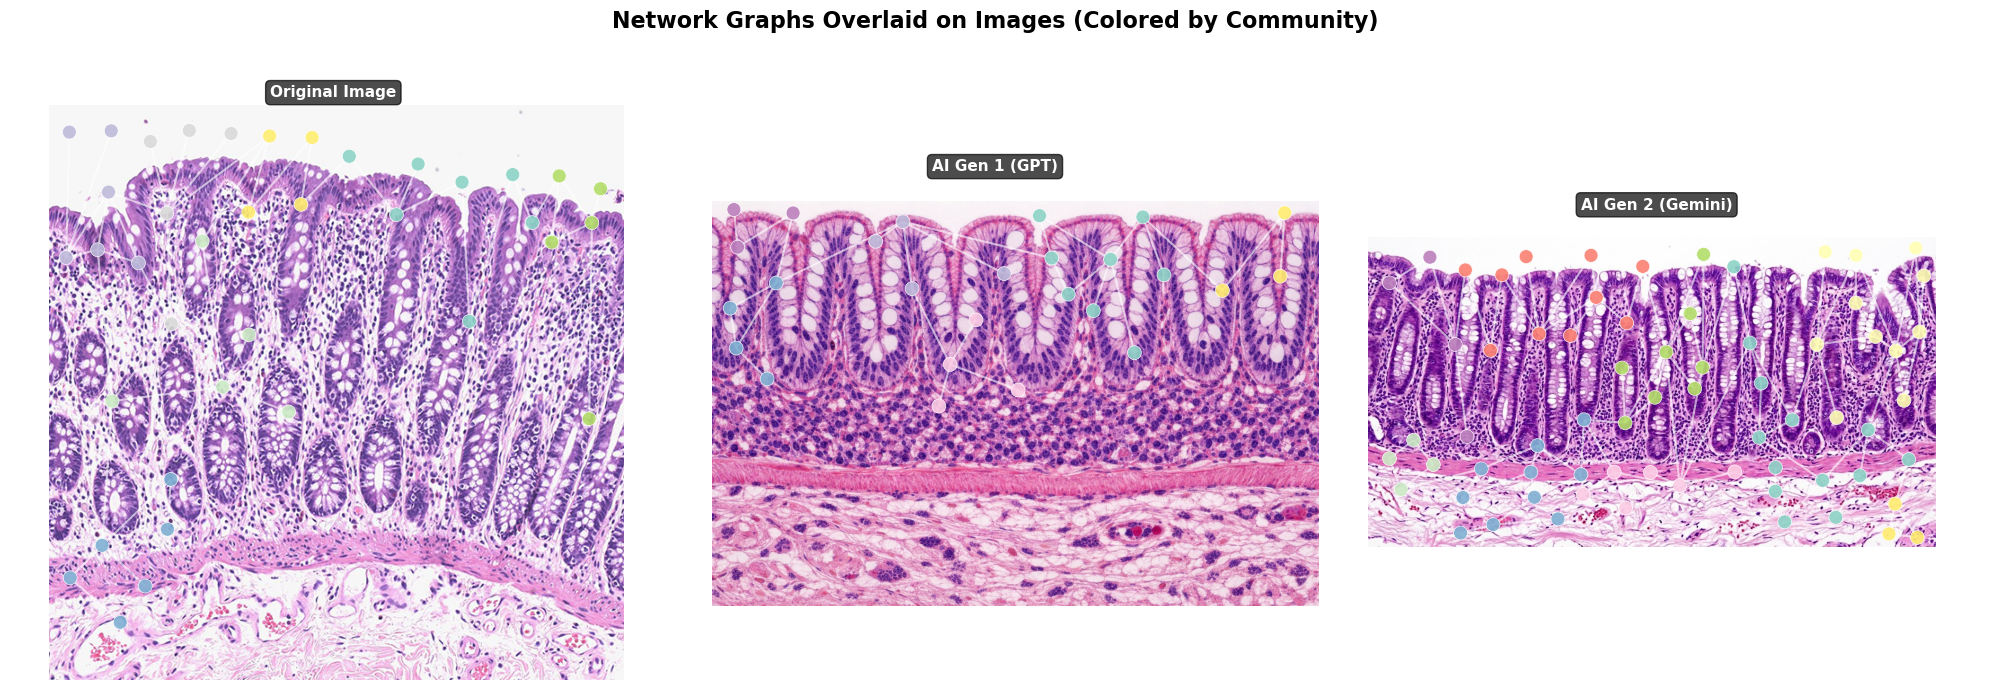

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, data) in zip(axes, all_data.items()):
    image = data['image']
    analysis = data['analysis']
    
    if image is not None and analysis is not None:
        draw_network_on_image(
            ax, image, 
            analysis.get('graph'),
            analysis.get('nodes'),
            analysis.get('centrality'),
            title=name,
            color_by='community',
            node_size=100
        )
    else:
        if image is not None:
            ax.imshow(image)
        ax.text(0.5, 0.5, 'No analysis data', ha='center', va='center', 
                fontsize=14, color='white', bbox=dict(facecolor='red', alpha=0.7))
        ax.set_title(name)
        ax.axis('off')

plt.suptitle('Network Graphs Overlaid on Images (Colored by Community)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Network Graphs Overlaid on Images (Betweenness Centrality)

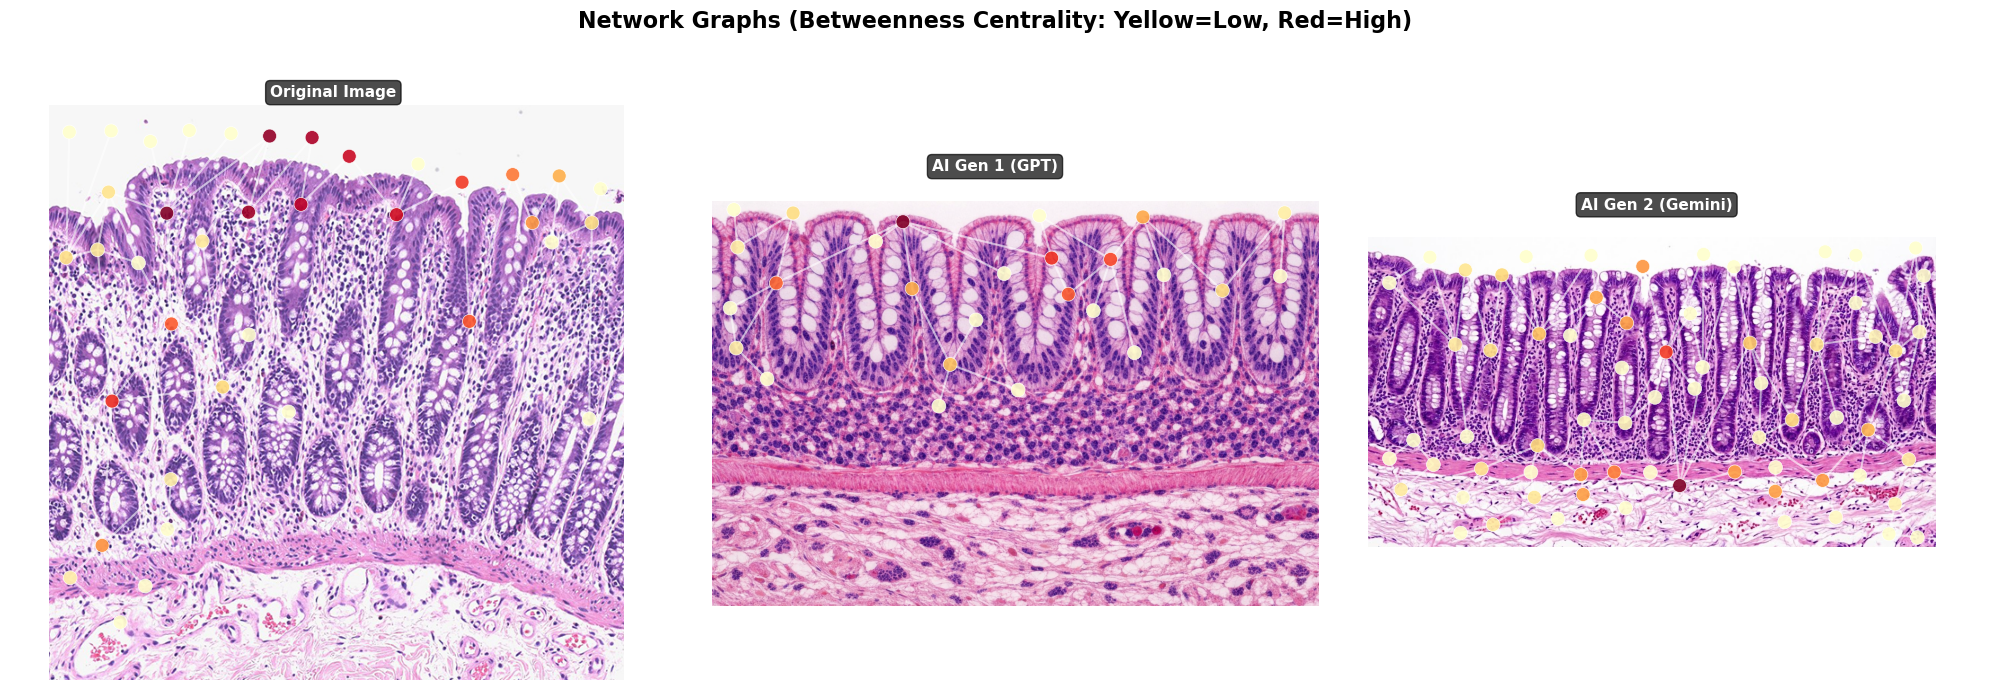

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, data) in zip(axes, all_data.items()):
    image = data['image']
    analysis = data['analysis']
    
    if image is not None and analysis is not None:
        draw_network_on_image(
            ax, image, 
            analysis.get('graph'),
            analysis.get('nodes'),
            analysis.get('centrality'),
            title=name,
            color_by='betweenness',
            node_size=100
        )
    else:
        if image is not None:
            ax.imshow(image)
        ax.text(0.5, 0.5, 'No analysis data', ha='center', va='center',
                fontsize=14, color='white', bbox=dict(facecolor='red', alpha=0.7))
        ax.set_title(name)
        ax.axis('off')

plt.suptitle('Network Graphs (Betweenness Centrality: Yellow=Low, Red=High)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Standalone Network Graph Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, data) in zip(axes, all_data.items()):
    analysis = data['analysis']
    
    if analysis is not None:
        draw_network_standalone(
            ax,
            analysis.get('graph'),
            analysis.get('centrality'),
            title=name,
            color_by='community',
            node_size=150
        )
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
        ax.set_title(name)
        ax.axis('off')

plt.suptitle('Network Graph Structure (Spring Layout)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Detailed View - Original + Network Overlay per Image

In [ ]:
for name, data in all_data.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    image = data['image']
    analysis = data['analysis']
    
    # Left: Original image
    if image is not None:
        axes[0].imshow(image)
        axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, 'Image not available', ha='center', va='center')
    axes[0].axis('off')
    
    # Right: Network overlay
    if image is not None and analysis is not None:
        G = analysis.get('graph')
        draw_network_on_image(
            axes[1], image,
            G,
            analysis.get('nodes'),
            analysis.get('centrality'),
            title='Network Overlay',
            color_by='community',
            node_size=120,
            show_labels=True
        )
        
        if G:
            stats = f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Density: {nx.density(G):.4f}"
            fig.text(0.5, 0.02, stats, ha='center', fontsize=11, 
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    else:
        axes[1].text(0.5, 0.5, 'No analysis data', ha='center', va='center', fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle(name, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
    print()

## 6. Graph Statistics Comparison

In [ ]:
stats_data = []

for name, data in all_data.items():
    analysis = data['analysis']
    row = {'Image': name}
    
    if analysis and analysis.get('graph'):
        G = analysis['graph']
        row['Nodes'] = G.number_of_nodes()
        row['Edges'] = G.number_of_edges()
        row['Density'] = round(nx.density(G), 4)
        row['Connected'] = nx.is_connected(G)
        row['Components'] = nx.number_connected_components(G)
        
        degrees = [d for n, d in G.degree()]
        row['Avg Degree'] = round(np.mean(degrees), 2)
        row['Max Degree'] = max(degrees)
        
        if analysis.get('centrality') is not None and 'community_id' in analysis['centrality'].columns:
            row['Communities'] = analysis['centrality']['community_id'].nunique()
        else:
            row['Communities'] = '-'
    else:
        for col in ['Nodes', 'Edges', 'Density', 'Connected', 'Components', 'Avg Degree', 'Max Degree', 'Communities']:
            row[col] = '-'
    
    stats_data.append(row)

stats_df = pd.DataFrame(stats_data)
print("📊 Graph Statistics Comparison")
print("=" * 80)
display(stats_df.set_index('Image').T)

## 7. Large Network Overlay (Individual)

In [ ]:
for name, data in all_data.items():
    image = data['image']
    analysis = data['analysis']
    
    if image is not None and analysis is not None and analysis.get('graph'):
        fig, ax = plt.subplots(1, 1, figsize=(14, 12))
        
        draw_network_on_image(
            ax, image,
            analysis.get('graph'),
            analysis.get('nodes'),
            analysis.get('centrality'),
            title=name,
            color_by='community',
            node_size=150,
            edge_alpha=0.7,
            show_labels=True
        )
        
        plt.tight_layout()
        plt.show()
        print()